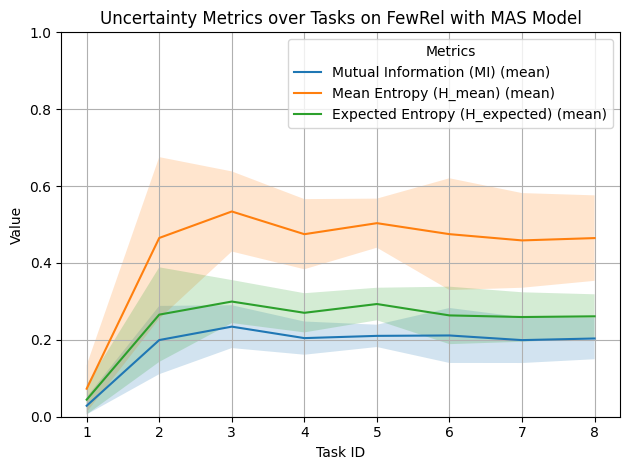

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Full data
# -----------------------------
data = pd.read_json("/Users/sefika/phd_projects/llm-catastrophic-re/results_all/un-metrics/mas_fewrel_uncertainty_metrics.json").to_dict(orient="records")

# -----------------------------
# DataFrame and statistics
# -----------------------------
df = pd.DataFrame(data)

stats = df.groupby("task_id")[["mi", "H_mean", "H_expected"]].agg(["mean", "std"])
stats.columns = ["_".join(col) for col in stats.columns]
stats = stats.reset_index()

# -----------------------------
# Plot with shaded std
# -----------------------------
plt.figure()
labels = ['Mutual Information (MI)', 'Mean Entropy (H_mean)', 'Expected Entropy (H_expected)']
for metric, label in zip(["mi", "H_mean", "H_expected"], labels):
    mean = stats[f"{metric}_mean"]
    std = stats[f"{metric}_std"]
    x = stats["task_id"]

    plt.plot(x, mean, label=f"{label} (mean)")
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Task ID")
plt.ylabel("Value")
plt.title("Uncertainty Metrics over Tasks on FewRel with MAS Model")
plt.legend(title="Metrics")

plt.ylim(0, 1.0) 
plt.grid(True)
plt.tight_layout()
plt.savefig("fewrel_mas_uncertainty_metrics.pdf", dpi=300)
plt.show()
